# Business problem find
1. you need to calculate the monthly sales of the store and identify wich month had the highest sales and which month had the lowest sales.
2. You need to analyze sales based on product categories and determine which category had the lowest sales and which category has the highest sales.
3. the sales analysis needs to be done based on sub-categories.
4. You need to analyze the monthly profit from sales and determine which month had the highest profit.
5. Analyze the profit by category and sub-category.
6. Analyze the sales and profit by customer segment.
7. Analyze the sales to profit ratio.

In [1]:
import pandas as pd

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
import plotly.colors as colors
pio.templates.default = 'plotly_white'           # set default color is white


In [2]:
df = pd.read_csv('Superstore.csv', encoding='latin1')

# 1. Show all columns without truncation
pd.set_option("display.max_columns", None)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

## Converting Date Formate

In [5]:
# Change data type of Order date & ship date
# df['Order Date']

# 1. convert to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

df['Ship Date'] = pd.to_datetime(df['Ship Date'])


## Create New Columns - order Month, Weeak, Year 

In [6]:
df['order month'] = df['Order Date'].dt.month
df['order day of week'] = df['Order Date'].dt.dayofweek 
df['order year'] = df['Order Date'].dt.year

## Monthly Sales Analysis

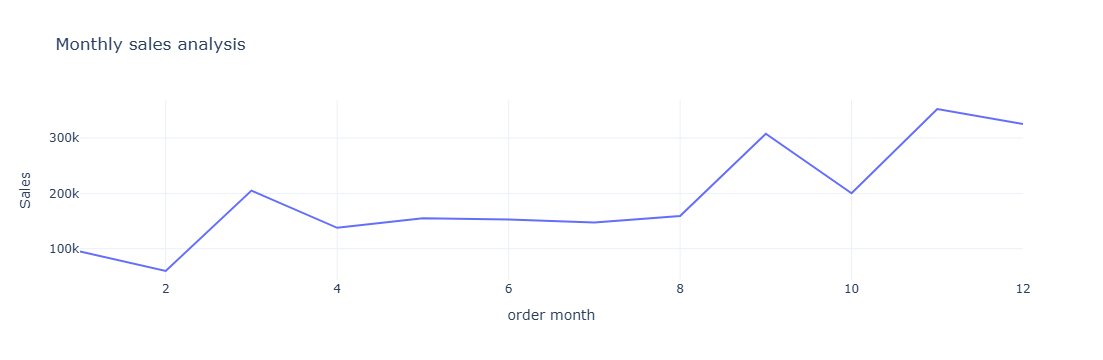

In [7]:
sales_by_month = df.groupby('order month')['Sales'].sum().reset_index()
sales_by_month

# visualization
fig = px.line(data_frame=sales_by_month, x='order month', y='Sales', title='Monthly sales analysis')
fig.show()

## Sales By Category

In [8]:
sales_by_category = df.groupby('Category')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)
sales_by_category

# Visualization
fig = px.pie(sales_by_category, names='Category', values='Sales', hole=0.4, color_discrete_sequence=colors.qualitative.Pastel)
fig.update_traces(textposition='inside', textinfo='percent+label')
fig.update_layout(title_text='Sales Analysis by Category')
fig.show()

# Sales by Sub-categories
### the sales analysis needs to be done based on sub-categories.


In [9]:
sales_by_sub_categories = df.groupby('Sub-Category')['Sales'].sum().reset_index().sort_values(by='Sales', ascending=False)
sales_by_sub_categories

,Sub-Category,Sales
13,Phones,330007.0540
5,Chairs,328449.1030
14,Storage,223843.6080
16,Tables,206965.5320
3,Binders,203412.7330
11,Machines,189238.6310
0,Accessories,167380.3180
6,Copiers,149528.0300
4,Bookcases,114879.9963
1,Appliances,107532.1610


In [10]:
# Visualization
fig = px.bar(sales_by_sub_categories, x='Sub-Category', y='Sales', title='sales by sub-categories')
fig.show()

## Monthly Profit Analysys

In [11]:
# Profit by month
profit_by_month = df.groupby('order month')['Profit'].sum().reset_index().sort_values(by='Profit', ascending=False)
profit_by_month

,order month,Profit
11,12,43369.1919
8,9,36857.4753
10,11,35468.4265
9,10,31784.0413
2,3,28594.6872
4,5,22411.3078
7,8,21776.9384
5,6,21285.7954
6,7,13832.6648
3,4,11587.4363


In [12]:
# Visualization

fig = px.bar(profit_by_month, x='order month', y='Profit', title='Profit by Month')
fig.show()

## Profit by categories

In [13]:
profit_by_categories = df.groupby('Category')['Profit'].sum().reset_index().sort_values(by='Profit')
profit_by_categories

,Category,Profit
0,Furniture,18451.2728
1,Office Supplies,122490.8008
2,Technology,145454.9481


In [14]:
# Visualization
fig = px.pie(profit_by_categories, names='Category', values='Profit', title='Profit by categories', color_discrete_sequence=colors.qualitative.Pastel)
fig.update_traces(textposition='inside', textinfo='percent + label')
fig.show()

## Profit by sub-categories

In [15]:
profit_by_sub_categories = df.groupby('Sub-Category')['Profit'].sum().reset_index().sort_values(by='Profit')
profit_by_sub_categories

,Sub-Category,Profit
16,Tables,-17725.4811
4,Bookcases,-3472.5560
15,Supplies,-1189.0995
8,Fasteners,949.5182
11,Machines,3384.7569
10,Labels,5546.2540
2,Art,6527.7870
7,Envelopes,6964.1767
9,Furnishings,13059.1436
1,Appliances,18138.0054


In [16]:
# Visualization
fig = px.bar(profit_by_sub_categories, y='Profit',x='Sub-Category', title='profit and loss by sub-categories')
fig.show()

# fig = px.pie(profit_by_sub_categories, names='Sub-Category', values='Profit', title='Profit by sub-categories', color_discrete_sequence=colors.qualitative.Pastel)
# fig.update_traces(textposition='inside', textinfo='percent + label')
# fig.show()

## Sales & Profit By Customer segment

In [17]:
# sales_frofit_by_cutomer = df.groupby('Segment').agg(sales = ('Sales', 'sum'),
#                                                    profit = ('Profit', 'sum')).reset_index()

sales_frofit_by_cutomer = df.groupby('Segment').agg({'Sales':'sum', 'Profit':'sum'}).reset_index()
sales_frofit_by_cutomer

,Segment,Sales,Profit
0,Consumer,1.161401e+06,134119.2092
1,Corporate,7.061464e+05,91979.1340
2,Home Office,4.296531e+05,60298.6785


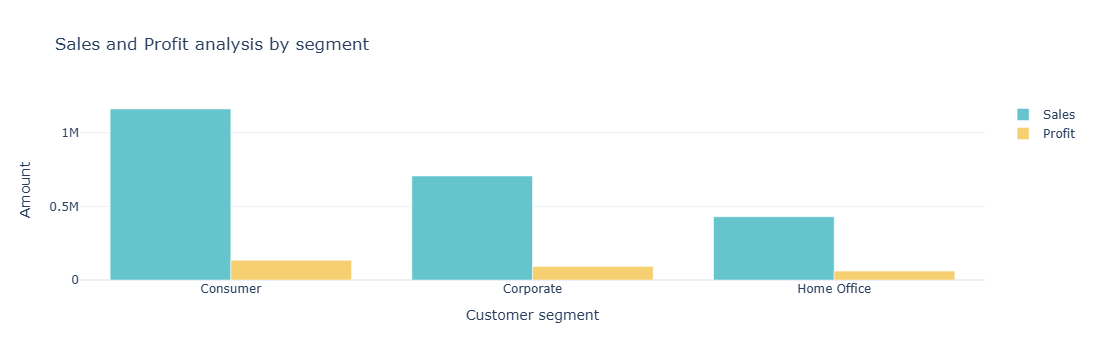

In [18]:
# Visualization
color_palette = colors.qualitative.Pastel
fig = go.Figure()

# Add Sales trace
fig.add_trace(go.Bar(
    x=sales_frofit_by_cutomer['Segment'],
    y=sales_frofit_by_cutomer['Sales'],
    name='Sales',
    marker_color=color_palette[0]
))

# Add Profit trace
fig.add_trace(go.Bar(
    x=sales_frofit_by_cutomer['Segment'],
    y=sales_frofit_by_cutomer['Profit'],
    name='Profit',
    marker_color=color_palette[1]
))

fig.update_layout(
    title='Sales and Profit analysis by segment',
    xaxis_title='Customer segment',
    yaxis_title='Amount',
    barmode='group'  # Groups bars side-by-side for comparison
)

fig.show()

## Sales by Profit Ratio

In [19]:
sales_by_profit_ratio = df.groupby('Segment').agg({'Sales':'sum', 'Profit':'sum'})
s_p_r = sales_by_profit_ratio['Sales'] / sales_by_profit_ratio['Profit']
s_p_r

Segment
Consumer       8.659471
Corporate      7.677245
Home Office    7.125416
dtype: float64

In [20]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,order month,order day of week,order year
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11,1,2016
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,11,1,2016
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,6,6,2016
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10,6,2015
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10,6,2015


## save dataframe

In [21]:
df.to_csv('Clean_Superstore.csv', index=False)
print('file saved successfully ✓')

file saved successfully ✓


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,order month,order day of week,order year
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,11,1,2016
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,11,1,2016
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,6,6,2016
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,10,6,2015
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,10,6,2015
